# Predicting Customer Buying Behaviour - British Airways

*Goal*: Create a machine learning model to determine the features that have the most impact on a customer's likelihood of completing a booking with British Airways. Provide accuracy checks and cross-validation statistics as well as visualizations. Generate a one-slide presentation summary of your findings.

*Dependencies*: pandas, numpy, matplotlib, sklearn

*To Run*: python Predicting_Customer_Buying_Behavior.py

In [21]:
#Imports
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

In [22]:
#Import the Dataset
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


## Exploratory Data Analysis

*Provided Dataset Information*
To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [24]:
#Data Preparation - Convert datatypes to more usable forms
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [25]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [26]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [27]:
#View dataset again with new mapped data
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [28]:
#Determine shape of the dataset for test-train split etc
df.shape

(50000, 14)

In [29]:
#Look at initially how many people actually completed their booking (compared to total data sets)
df["booking_complete"].value_counts()

## Notice that the dataset is unbalanced - there is vastly more cases of non-completed bookings than completed ones

booking_complete
0    42522
1     7478
Name: count, dtype: int64

### Look at individual factor's impact first

In [30]:
#look at individual relations - arbitrarily look at number of passengers, sales channel, and flight duration for first analysis

df.groupby("num_passengers")["booking_complete"].mean()

num_passengers
1    0.142096
2    0.160184
3    0.166950
4    0.154148
5    0.194296
6    0.186851
7    0.157895
8    0.134831
9    0.196970
Name: booking_complete, dtype: float64

*Analysis*: About 14% of the people who book trips solo complete their booking. About 18.6% of the people who book in a group of six complete their booking.

In [31]:
df.groupby("sales_channel")["booking_complete"].mean()

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64

*Analysis*: About 15% of the people who book on the Internet complete their booking. About 11% of the people who book on their Mobile complete their booking.

In [32]:
df.groupby("flight_duration")["booking_complete"].mean()

flight_duration
4.67    0.246081
4.72    0.241036
4.75    0.333865
4.83    0.121795
5.00    0.240664
5.07    0.236328
5.13    0.224000
5.33    0.248391
5.52    0.077961
5.62    0.095040
6.33    0.163866
6.42    0.214162
6.62    0.171574
7.00    0.218731
7.42    0.151786
7.57    0.176367
8.15    0.003215
8.58    0.077818
8.67    0.234201
8.83    0.116253
9.50    0.135135
Name: booking_complete, dtype: float64

*Analysis*: About 23% of the people who book an 8.67 hr flight complete their booking. About 24.6% of people who book a 4.67 hr flight complete their booking.

### Feature Engineering

Some interesting categories we can create and investigate include:
- classifying whether a booking is a group or a solo trip (Does social pressure increases chances of completing a booking?)
- assessing the total number of extras a customer adds to their booking (Does an increased number of extras purchased correspond to higher chances of completed booking?)

In [33]:
#creating group booking feature

df["group_booking"] = (df["num_passengers"]>1).astype(int)

In [34]:
#creating total extras feature (maybe if they get more extras they are more committed to flying)
df["total_extras"]=(df["wants_extra_baggage"]+df["wants_preferred_seat"]+df["wants_in_flight_meals"])

## Machine Learning Model - Random Forest
### Preparing the Data

In [35]:
#Look at the number of unique values exist in each feature category. This helps us determine which features we will have to hot encode. 
df.nunique()

num_passengers             9
sales_channel              2
trip_type                  3
purchase_lead            470
length_of_stay           335
flight_hour               24
flight_day                 7
route                    799
booking_origin           104
wants_extra_baggage        2
wants_preferred_seat       2
wants_in_flight_meals      2
flight_duration           21
booking_complete           2
group_booking              2
total_extras               4
dtype: int64

In [36]:
#Make the different routes a measure of popularity, not by unique routes. This reduces the complexity of the dataset.

route_counts = df["route"].value_counts()

df["route_frequency"]=df["route"].map(route_counts)

In [37]:
#Do a similar thing for booking origin location
origin_counts = df["booking_origin"].value_counts()
df["origin_frequency"] = df["booking_origin"].map(origin_counts)

In [38]:
#now drop the original columns, route and booking origin, for clarity

df = df.drop(["route", "booking_origin"], axis = 1)

### Random Forest Model

In [39]:
#Create train/test split

X = df.drop("booking_complete", axis=1)
y = df["booking_complete"]

In [40]:
#hot encode the remaining columns

X = pd.get_dummies(X)

X.shape

(50000, 18)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y)

In [42]:
#Check the shapes of the data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(35000, 18)
(15000, 18)
(35000,)
(15000,)


In [43]:
#create model 

mymodel = RandomForestClassifier(
    n_estimators= 100,
    class_weight = "balanced")

#fit the model to data
mymodel.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [44]:
#Predicted Results
y_pred = mymodel.predict(X_test)

### Model Evaluation

In [45]:
#evaluation report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     12757
           1       0.51      0.09      0.15      2243

    accuracy                           0.85     15000
   macro avg       0.68      0.54      0.53     15000
weighted avg       0.81      0.85      0.80     15000



*Analysis*

The dataset is heavily biased towards customers that do not complete their bookings (demonstrated by support of ~12700, compared to ~2200).

When the model predicted an incomplete booking, it was correct 86% of the time. The model correctly found 99% of all the incomplete booking cases. 

When the model predicted a complete booking, it was correct 51% of the time. The model correctly found 9% of the complete booking cases. These accuracies could be improved in future models.

*Accuracy*

92% accurate when predicting incomplete bookings
15% accurate when predicted complete bookings

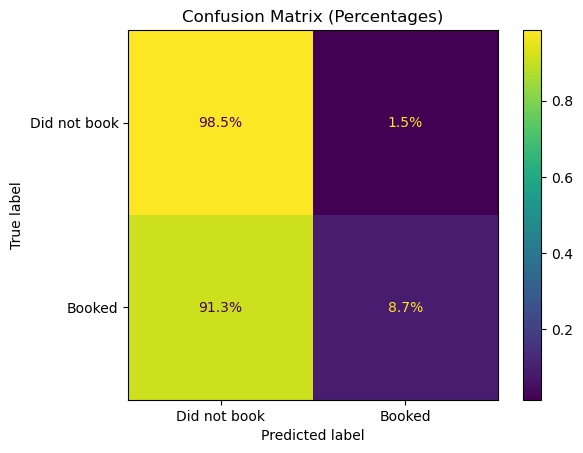

In [46]:
#confusion matrix visualization
conf_mat= confusion_matrix(y_test,y_pred, normalize ="true")

disp = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ["Did not book", "Booked"])
disp.plot(values_format = "0.1%")
plt.title("Confusion Matrix (Percentages)")
plt.show()

*Analysis*

The Confusion Matrix shows that the model correctly predicted 98.5% of the cases where customers did not complete their booking. It only correctly predicted 8.7% of the cases where the customers completed their bookings. 

In [47]:
#cross validation and score
cross_val_scores = cross_val_score(mymodel, 
                                   X, 
                                   y,
                                   cv=5,
                                   scoring = "f1")
print(cross_val_scores)
print("Mean F1 Score:", cross_val_scores.mean())

[0.01710526 0.19348837 0.00619469 0.00292588 0.32573485]
Mean F1 Score: 0.10908981126182557


## Visualizations

In [48]:
#Visualizing data feature importances
mymodel.feature_importances_

array([0.03222264, 0.16572347, 0.12300215, 0.12338019, 0.08058377,
       0.01132375, 0.01072692, 0.0126303 , 0.07660106, 0.01401212,
       0.02354322, 0.14449626, 0.16604007, 0.00612542, 0.00659037,
       0.00024789, 0.0011023 , 0.00164809])

In [49]:
#Make a new dataframe for the importances for visualization

importances = pd.DataFrame({"Feature": X.columns, "Importance":mymodel.feature_importances_})

In [50]:
#sort the features increasing to decreasing importance
importances = importances.sort_values(by="Importance", ascending = False)

Text(0.5, 1.0, 'Top Features for Booking Completion')

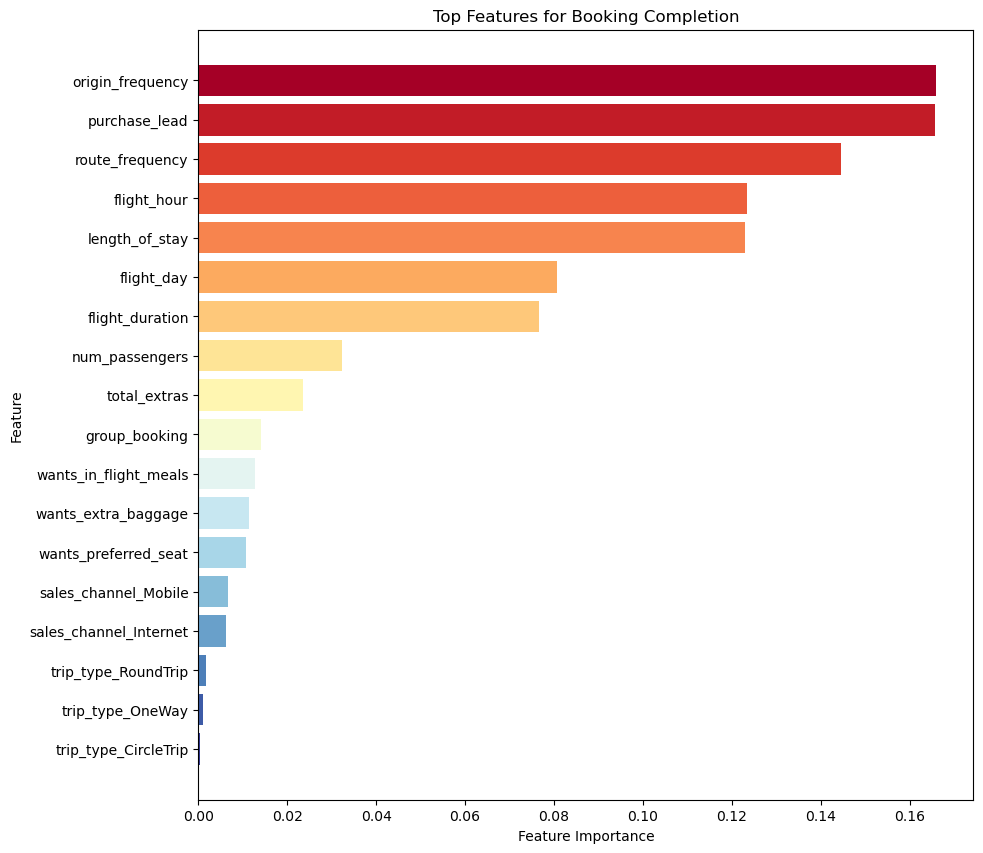

In [51]:
#create visualization

colors = plt.cm.RdYlBu(np.linspace(0, 1, len(importances)))

plt.figure(figsize = (10,10))
plt.barh(importances["Feature"], importances["Importance"], color = colors)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for Booking Completion")

Text(0.5, 1.0, 'Top Features for Booking Completion')

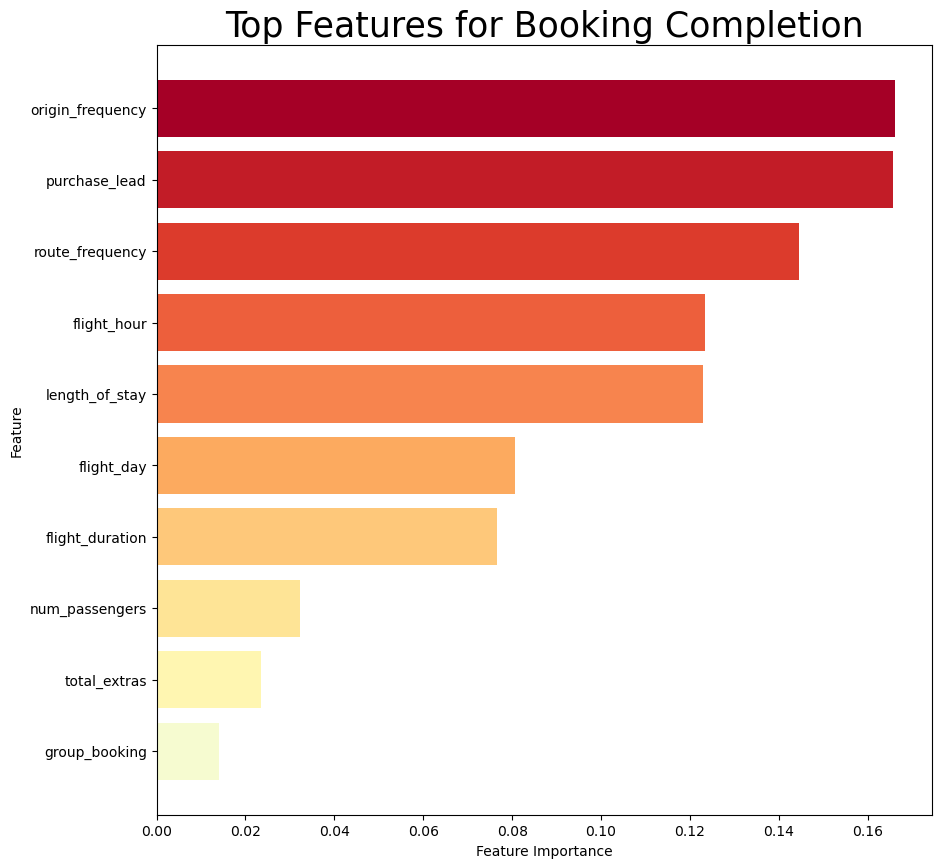

In [52]:
#only look at top 5 features

top_5 = importances.head(10)


colors2 = plt.cm.RdYlBu(np.linspace(0, 1, len(importances)))

plt.figure(figsize = (10,10))
plt.barh(top_5["Feature"], top_5["Importance"], color = colors2)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for Booking Completion", size = 25)